In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

df = pd.read_csv('data/wbcd.csv')
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,points_worst,symmetry_worst,dimension_worst
0,87139402,B,12.32,12.39,78.85,464.1,0.10280,0.06981,0.03987,0.03700,...,13.50,15.64,86.97,549.1,0.1385,0.1266,0.12420,0.09391,0.2827,0.06771
1,8910251,B,10.60,18.95,69.28,346.4,0.09688,0.11470,0.06387,0.02642,...,11.88,22.94,78.28,424.8,0.1213,0.2515,0.19160,0.07926,0.2940,0.07587
2,905520,B,11.04,16.83,70.92,373.2,0.10770,0.07804,0.03046,0.02480,...,12.41,26.44,79.93,471.4,0.1369,0.1482,0.10670,0.07431,0.2998,0.07881
3,868871,B,11.28,13.39,73.00,384.8,0.11640,0.11360,0.04635,0.04796,...,11.92,15.77,76.53,434.0,0.1367,0.1822,0.08669,0.08611,0.2102,0.06784
4,9012568,B,15.19,13.21,97.65,711.8,0.07963,0.06934,0.03393,0.02657,...,16.20,15.73,104.50,819.1,0.1126,0.1737,0.13620,0.08178,0.2487,0.06766


In [45]:
print('Values of Diagnosis')
print(df.diagnosis.value_counts())

Values of Diagnosis
diagnosis
B    357
M    212
Name: count, dtype: int64


In [29]:
print('Test Accuracy', clf.score(X_test, y_test))


Test Accuracy 1.0


In [46]:
print('Mean of area_mean', df.area_mean.mean())
print('Mean of radius_mean', df.radius_mean.mean())
print('Mean of smoothness_mean', df.smoothness_mean.mean())

Mean of area_mean 654.8891036906855
Mean of radius_mean 14.127291739894552
Mean of smoothness_mean 0.09636028119507908


In [52]:
# Define X and y

X = df.drop(['id', 'diagnosis'], axis='columns')
y = df.diagnosis

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2, test_size=0.2, stratify=y)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
X.head()

(455, 30)
(114, 30)
(455,)
(114,)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,points_mean,symmetry_mean,dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,points_worst,symmetry_worst,dimension_worst
0,12.32,12.39,78.85,464.1,0.10280,0.06981,0.03987,0.03700,0.1959,0.05955,...,13.50,15.64,86.97,549.1,0.1385,0.1266,0.12420,0.09391,0.2827,0.06771
1,10.60,18.95,69.28,346.4,0.09688,0.11470,0.06387,0.02642,0.1922,0.06491,...,11.88,22.94,78.28,424.8,0.1213,0.2515,0.19160,0.07926,0.2940,0.07587
2,11.04,16.83,70.92,373.2,0.10770,0.07804,0.03046,0.02480,0.1714,0.06340,...,12.41,26.44,79.93,471.4,0.1369,0.1482,0.10670,0.07431,0.2998,0.07881
3,11.28,13.39,73.00,384.8,0.11640,0.11360,0.04635,0.04796,0.1771,0.06072,...,11.92,15.77,76.53,434.0,0.1367,0.1822,0.08669,0.08611,0.2102,0.06784
4,15.19,13.21,97.65,711.8,0.07963,0.06934,0.03393,0.02657,0.1721,0.05544,...,16.20,15.73,104.50,819.1,0.1126,0.1737,0.13620,0.08178,0.2487,0.06766


In [53]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)

In [54]:
clf = KNeighborsClassifier()

scores = cross_val_score(clf, X_train_scaled, y_train, cv=5)
print(scores)
print('Validation accuracy with MinMaxScaler', scores.mean())

[0.94505495 0.96703297 0.96703297 0.97802198 0.97802198]
Validation accuracy with MinMaxScaler 0.9670329670329669


In [57]:
scaler = MinMaxScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = KNeighborsClassifier()
clf.fit(X_train_scaled, y_train)
print('Test Accuracy', clf.score(X_test_scaled, y_test))

Test Accuracy 0.9736842105263158


In [59]:
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)
training_accuracy = []
validation_accuracy = []

for k in range(1,15) :
    clf = KNeighborsClassifier(n_neighbors=k) 
    clf.fit(X_train, y_train)
    training_accuracy.append(clf.score(X_train, y_train))
    scores = cross_val_score(clf, X_train, y_train, cv=5)
    print("k: ", k , "   validation accuracy", scores.mean())
    validation_accuracy.append(scores.mean())

k:  1    validation accuracy 0.956043956043956
k:  2    validation accuracy 0.9604395604395604
k:  3    validation accuracy 0.9692307692307691
k:  4    validation accuracy 0.9648351648351647
k:  5    validation accuracy 0.9670329670329669
k:  6    validation accuracy 0.9714285714285713
k:  7    validation accuracy 0.9736263736263735
k:  8    validation accuracy 0.9648351648351647
k:  9    validation accuracy 0.9648351648351647
k:  10    validation accuracy 0.9626373626373625
k:  11    validation accuracy 0.9626373626373625
k:  12    validation accuracy 0.9648351648351647
k:  13    validation accuracy 0.9626373626373625
k:  14    validation accuracy 0.9670329670329669


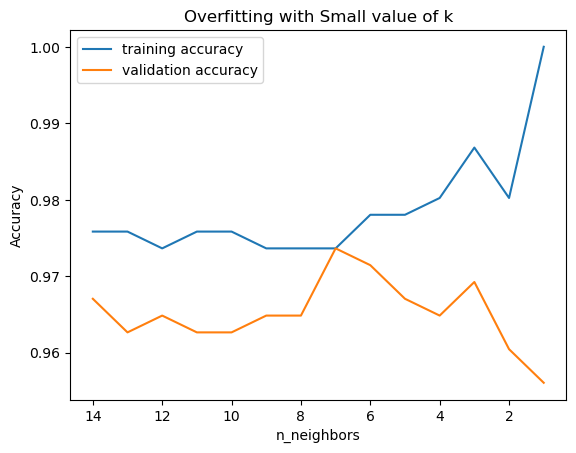

In [63]:
plt.plot(range(1,15), training_accuracy , label="training accuracy")
plt.plot(range(1,15), validation_accuracy, label="validation accuracy")
plt.xlabel("n_neighbors")
plt.ylabel("Accuracy")
plt.legend()
plt.title('Overfitting with Small value of k')
ax = plt.gca()
ax.invert_xaxis()
plt.savefig('plots/overfitting.png')

In [64]:
clf = KNeighborsClassifier(n_neighbors=11)    
clf.fit(X_train, y_train)

# yPredict = clf.predict(X_test)
# print(accuracy_score(y_test, yPredict))
print('Test Accuracy', clf.score(X_test, y_test))

Test Accuracy 0.956140350877193


In [65]:
yhat = clf.predict(X_test)
# cm = confusion_matrix(y_test, yhat)
cm = confusion_matrix(y_test, yhat, labels=['B','M'])
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix: \n", cm)

Confusion matrix: 
 [[69  3]
 [ 2 40]]
